All libraries imported successfully!
Images downloaded!


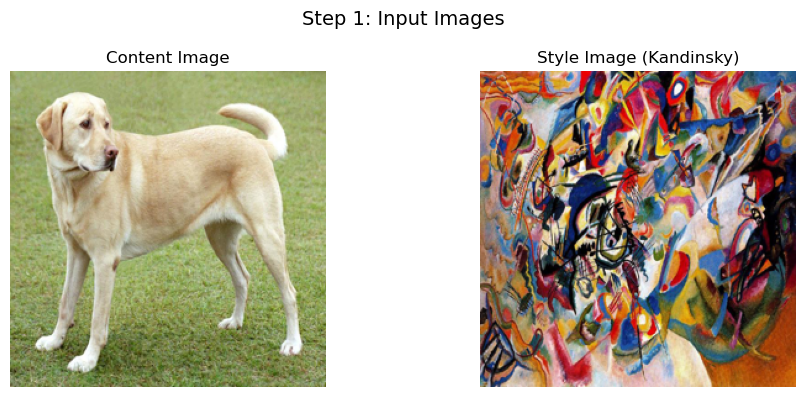

VGG19 feature extractor built!
Target features extracted!
Starting Neural Style Transfer...

Epoch 1/10  |  Loss: 1027809792.00
Epoch 2/10  |  Loss: 346335328.00
Epoch 3/10  |  Loss: 194666288.00
Epoch 4/10  |  Loss: 140345168.00
Epoch 5/10  |  Loss: 113591760.00
Epoch 6/10  |  Loss: 97653712.00
Epoch 7/10  |  Loss: 86797504.00
Epoch 8/10  |  Loss: 78814120.00
Epoch 9/10  |  Loss: 72669864.00
Epoch 10/10  |  Loss: 67824072.00


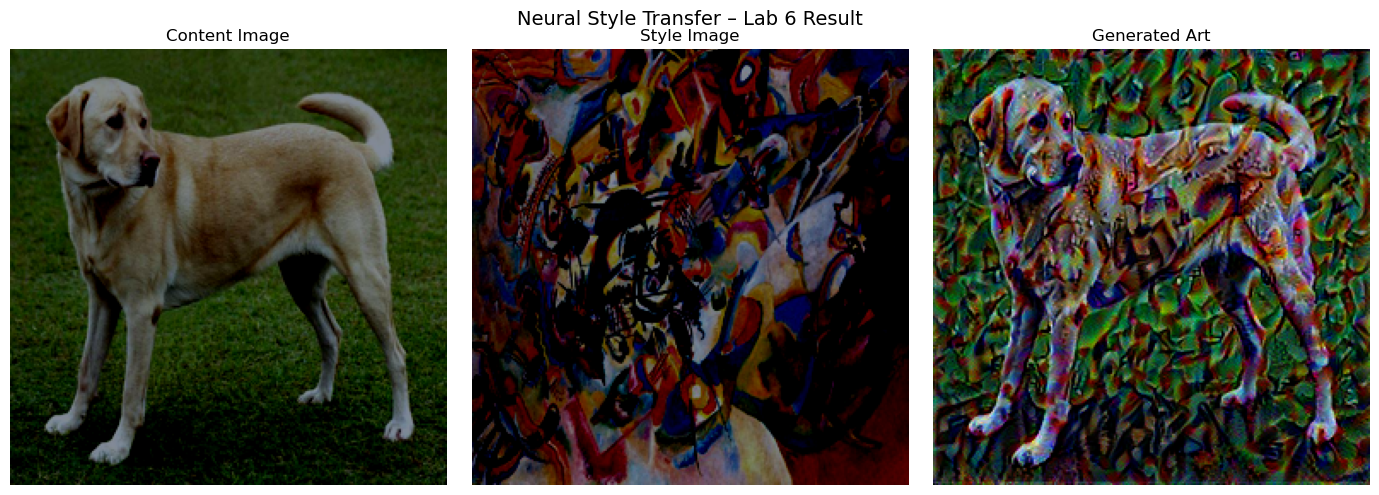

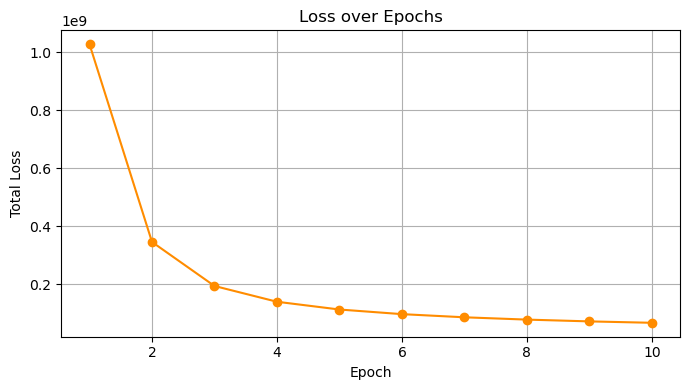


Neural Style Transfer Complete!


In [1]:
# ============================================================
# LAB 6 - Neural Style Transfer using Deep Learning (VGG19)
# Assignment: Create Art with Neural Style Transfer
# ============================================================

# ── STEP 1: Import Libraries ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from PIL import Image

print("All libraries imported successfully!")


# ── STEP 2: Download Content and Style Images ─────────────
content_path = tf.keras.utils.get_file(
    "content.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
)
style_path = tf.keras.utils.get_file(
    "style.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg"
)
print("Images downloaded!")


# ── STEP 3: Helper Functions ──────────────────────────────

def load_image(path, max_dim=256):
    """Load an image, resize it, and prepare it for the model."""
    img = Image.open(path).convert("RGB")
    img = img.resize((max_dim, max_dim))
    img = np.array(img, dtype=np.float32)
    return np.expand_dims(img, axis=0)   # shape: (1, H, W, 3)

def deprocess(img):
    """Convert model tensor back to a viewable image."""
    img = np.squeeze(img.copy())          # remove batch dimension
    return np.clip(img, 0, 255).astype("uint8")

def preprocess_for_vgg(img):
    """Apply VGG19-specific preprocessing (subtracts ImageNet mean)."""
    # preprocess_input can handle tf.Tensor inputs directly
    # The conversion to numpy breaks the gradient tracking for tf.Variable.
    return preprocess_input(img)


# ── STEP 4: Load and Display Original Images ──────────────
content_image = load_image(content_path)
style_image   = load_image(style_path)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(deprocess(content_image))
plt.title("Content Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(deprocess(style_image))
plt.title("Style Image (Kandinsky)")
plt.axis("off")

plt.suptitle("Step 1: Input Images", fontsize=14)
plt.tight_layout()
plt.show()


# ── STEP 5: Build Feature Extractor using VGG19 ───────────
# VGG19 is a pretrained CNN. We use its intermediate layers
# to capture CONTENT (deep structure) and STYLE (textures).

# Content layer  → captures 'what' is in the image
CONTENT_LAYERS = ['block5_conv2']

# Style layers   → capture textures and artistic patterns
STYLE_LAYERS = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

def build_model(content_layers, style_layers):
    """Build a model that returns outputs from chosen VGG19 layers."""
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False                # freeze all weights

    all_layer_names = content_layers + style_layers
    outputs = [vgg.get_layer(name).output for name in all_layer_names]

    model = tf.keras.Model(inputs=vgg.input, outputs=outputs)
    return model

feature_extractor = build_model(CONTENT_LAYERS, STYLE_LAYERS)
print("VGG19 feature extractor built!")


# ── STEP 6: Gram Matrix (captures Style) ──────────────────
# The Gram Matrix measures correlations between feature maps.
# High correlation = recurring texture or pattern = "style".

def gram_matrix(feature_map):
    """Compute the Gram matrix for a feature map."""
    # feature_map shape: (1, H, W, C)
    result = tf.linalg.einsum('bijc,bijd->bcd', feature_map, feature_map)
    shape  = tf.shape(feature_map)
    num_locations = tf.cast(shape[1] * shape[2], tf.float32)
    return result / num_locations        # normalize


# ── STEP 7: Extract Target Features ───────────────────────

def get_features(image, model, num_content_layers):
    """Run image through the model and split content vs style outputs."""
    preprocessed = preprocess_for_vgg(image)
    outputs = model(preprocessed)

    content_outputs = outputs[:num_content_layers]
    style_outputs   = outputs[num_content_layers:]

    content_features = {name: val for name, val in zip(CONTENT_LAYERS, content_outputs)}
    style_features   = {name: gram_matrix(val) for name, val in zip(STYLE_LAYERS, style_outputs)}

    return content_features, style_features

num_content_layers = len(CONTENT_LAYERS)

# Extract features from content and style images
content_features, _             = get_features(content_image, feature_extractor, num_content_layers)
_,               style_features = get_features(style_image,   feature_extractor, num_content_layers)

print("Target features extracted!")


# ── STEP 8: Loss Functions ────────────────────────────────

def content_loss(generated_content, target_content):
    """Measures how similar the generated image's structure is to the content image."""
    return tf.reduce_mean((generated_content - target_content) ** 2)

def style_loss(generated_gram, target_gram):
    """Measures how similar the generated image's textures are to the style image."""
    return tf.reduce_mean((generated_gram - target_gram) ** 2)

def total_loss(generated_image, model, content_features, style_features,
               content_weight=1e4, style_weight=1e-2):
    """
    Combines content loss + style loss.
    - content_weight: how much to preserve content structure
    - style_weight  : how much to apply artistic style
    """
    gen_content, gen_style = get_features(generated_image, model, num_content_layers)

    c_loss = sum(content_loss(gen_content[name], content_features[name])
                 for name in CONTENT_LAYERS)

    s_loss = sum(style_loss(gen_style[name], style_features[name])
                 for name in STYLE_LAYERS)

    return content_weight * c_loss + style_weight * s_loss


# ── STEP 9: Run Style Transfer Optimization ───────────────
# We start with the content image and iteratively update its
# pixels to minimise the total loss using Adam optimizer.

# Initialize generated image as a copy of content image
generated_image = tf.Variable(content_image.copy(), dtype=tf.float32)

optimizer = tf.optimizers.Adam(learning_rate=5.0)

EPOCHS      = 10    # number of display checkpoints
STEPS_EACH  = 10    # optimization steps per checkpoint
# Total steps = EPOCHS × STEPS_EACH = 100
# (Increase STEPS_EACH to 100 for better results; takes ~5 min on Colab)

loss_history = []

print("Starting Neural Style Transfer...\n")

for epoch in range(EPOCHS):
    for step in range(STEPS_EACH):
        with tf.GradientTape() as tape:
            loss = total_loss(generated_image, feature_extractor,
                              content_features, style_features,
                              content_weight=1e4, style_weight=1e-2)

        grads = tape.gradient(loss, generated_image)
        optimizer.apply_gradients([(grads, generated_image)])

        # Clip pixel values to valid [0, 255] range after each step
        generated_image.assign(tf.clip_by_value(generated_image, 0.0, 255.0))

    loss_history.append(loss.numpy())
    print(f"Epoch {epoch + 1}/{EPOCHS}  |  Loss: {loss.numpy():.2f}")


# ── STEP 10: Display Final Result ─────────────────────────
final_image = deprocess(generated_image.numpy())

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(deprocess(content_image))
plt.title("Content Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(deprocess(style_image))
plt.title("Style Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final_image)
plt.title("Generated Art")
plt.axis("off")

plt.suptitle("Neural Style Transfer – Lab 6 Result", fontsize=14)
plt.tight_layout()
plt.show()


# ── STEP 11: Plot Loss Curve ──────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', color='darkorange')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nNeural Style Transfer Complete!")